# Task 4 — Feature Selection within rnCV
MLCB 2026 | Assignment #2

In [ ]:
import os, sys, warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))

from nested_cv_2 import RepeatedNestedCVFeatureSelection
from functions import load_data

os.makedirs('../figures', exist_ok=True)

## 4.0  Load Data & Define Winner Estimator

Replace `WINNER_NAME` and `winner_estimator` with whichever algorithm won Task 3.
Feature selection is run only for the winner, as the assignment specifies.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

SEED = 42

data = load_data('../data/students_dataset.csv')
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X = data.drop(columns=['num'])
y = data['num']

# Set this to the Task 3 winner
WINNER_NAME = 'LR'

all_estimators = {
    'LR': LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, random_state=SEED, l1_ratio=0.5),
    'GNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'RF': RandomForestClassifier(random_state=SEED),
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'XGBoost':  XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=SEED, verbose=0),
}

winner_estimator = {WINNER_NAME: all_estimators[WINNER_NAME]}
print(f'Winner: {WINNER_NAME}')
print(f'Features: {list(X.columns)}')

Winner: LR
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 4.1  Define Winner's Hyperparameter Space

In [ ]:
def lr_space(trial):
    return {'C': trial.suggest_float('C', 1e-3, 10, log=True),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0)}

def gnb_space(trial):
    return {'var_smoothing': trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True)}

def lda_space(trial):
    return {'solver': 'lsqr', 'shrinkage': trial.suggest_float('shrinkage', 0.0, 1.0)}

def rf_space(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': 'balanced'}

def lgbm_space(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 64),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'class_weight': 'balanced'}

def xgb_space(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': (y == 0).sum() / (y == 1).sum()}

def catboost_space(trial):
    return {'iterations': trial.suggest_int('iterations', 100, 500, step=100),
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
            'auto_class_weights': 'Balanced'}

all_spaces = {
    'LR': lr_space, 'GNB': gnb_space, 'LDA': lda_space,
    'RF': rf_space, 'LightGBM': lgbm_space,
    'XGBoost': xgb_space, 'CatBoost': catboost_space,
}

winner_space = {WINNER_NAME: all_spaces[WINNER_NAME]}
print('Hyperparameter space ready.')

Hyperparameter space ready.


## 4.2  Choose Number of Features to Retain

In [ ]:
N_FEATURES = 10 
print(f'Retaining top {N_FEATURES} features per outer fold.')

Retaining top 10 features per outer fold.


## 4.3  Run rnCV with Feature Selection (winner only)

In [ ]:
rncv_fs = RepeatedNestedCVFeatureSelection(
    estimators=winner_estimator,
    param_spaces=winner_space,
    categorical_cols=categorical_features, 
    numerical_cols=numerical_features,    
    R=10, N=5, K=3,
    n_trials=50,
    inner_metric='AUC',
    base_seed=42,
    use_feature_selection=True,
    n_features=N_FEATURES,
)

print(f'Running rnCV with feature selection (top {N_FEATURES}) ...')
rncv_fs.fit(X, y, tune=True)
print('Done.')

results_fs = rncv_fs.summary()
key_cols = [c for c in results_fs.columns if c.endswith('_median')]
print('\nResults (feature selection):')
display(results_fs[key_cols].round(4))

Running rnCV with feature selection (top 10) ...
Done.

Results (feature selection):


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median,Precision_median,PRAUC_median
Estimator,,,,,,,,
LR,0.6698,0.8996,0.8287,0.8095,0.7727,0.8846,0.85,0.8974


## 4.4  Compare: Full Features vs Selected Features

In [ ]:
rncv_full = RepeatedNestedCVFeatureSelection(
    estimators=winner_estimator,
    param_spaces=winner_space,
    categorical_cols=categorical_features,
    numerical_cols=numerical_features,
    R=10, N=5, K=3,
    n_trials=50,
    inner_metric='AUC',
    base_seed=42,
    use_feature_selection=False,
)

print('Running full-feature rnCV (winner only) for comparison ...')
rncv_full.fit(X, y, tune=True)
print('Done.')

results_full = rncv_full.summary()

Running full-feature rnCV (winner only) for comparison ...
Done.


In [ ]:
compare_metrics = ['MCC', 'AUC', 'BA', 'F1', 'Recall', 'Specificity']

rows = []
for m in compare_metrics:
    full_med = results_full.loc[WINNER_NAME, f'{m}_median']
    full_lo = results_full.loc[WINNER_NAME, f'{m}_CI_lo']
    full_hi = results_full.loc[WINNER_NAME, f'{m}_CI_hi']
    fs_med = results_fs.loc[WINNER_NAME, f'{m}_median']
    fs_lo = results_fs.loc[WINNER_NAME, f'{m}_CI_lo']
    fs_hi = results_fs.loc[WINNER_NAME, f'{m}_CI_hi']
    rows.append({
        'Metric': m,
        'Full (13 feats)': f'{full_med:.4f} [{full_lo:.4f}, {full_hi:.4f}]',
        f'Selected ({N_FEATURES} feats)': f'{fs_med:.4f} [{fs_lo:.4f}, {fs_hi:.4f}]',
        'Delta': round(fs_med - full_med, 4),
    })

compare_df = pd.DataFrame(rows).set_index('Metric')
print(f'\nPerformance comparison — {WINNER_NAME}:')
display(compare_df)


Performance comparison — LR:


,Full (13 feats),Selected (10 feats),Delta
Metric,,,
MCC,"0.6692 [0.6044, 0.6800]","0.6698 [0.6197, 0.7089]",0.0006
AUC,"0.9038 [0.8795, 0.9141]","0.8996 [0.8820, 0.9100]",-0.0042
BA,"0.8269 [0.8022, 0.8357]","0.8287 [0.8064, 0.8479]",0.0018
F1,"0.8048 [0.7860, 0.8205]","0.8095 [0.7860, 0.8293]",0.0047
Recall,"0.7727 [0.7273, 0.8182]","0.7727 [0.7391, 0.8182]",0.0000
Specificity,"0.8846 [0.8462, 0.9060]","0.8846 [0.8462, 0.9060]",0.0000


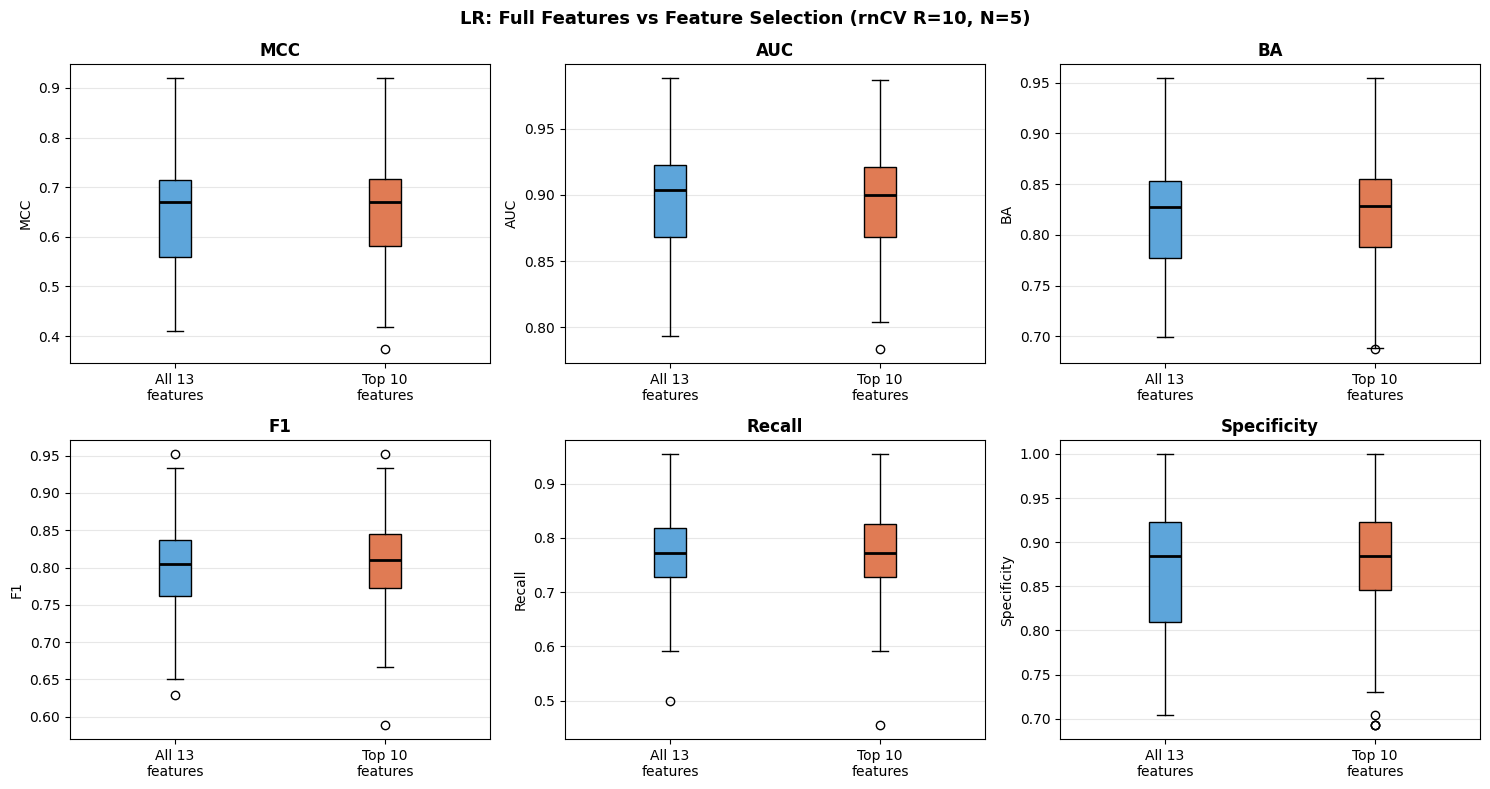

In [ ]:
# Box plot comparison: Full vs Selected
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, m in zip(axes, compare_metrics):
    full_vals = rncv_full.get_scores(WINNER_NAME)[m].values
    fs_vals   = rncv_fs.get_scores(WINNER_NAME)[m].values

    bp = ax.boxplot(
        [full_vals, fs_vals],
        patch_artist=True,
        medianprops=dict(color='black', lw=2),
        tick_labels=['All 13\nfeatures', f'Top {N_FEATURES}\nfeatures'],
    )
    colors = ['#5DA5DA', '#E07B54']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(m, fontweight='bold')
    ax.set_ylabel(m)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'{WINNER_NAME}: Full Features vs Feature Selection (rnCV R=10, N=5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_feature_selection_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

## 4.5  Feature Selection Frequency

In [12]:
freq_df = rncv_fs.get_selection_frequency(WINNER_NAME)

print(f'Feature selection frequency across {rncv_fs.R * rncv_fs.N} outer folds:')
display(freq_df)

# Threshold: features selected in ≥ 70% of folds are considered 'stable'
stable = freq_df[freq_df['selected_%'] >= 70]
print(f'\nStable features (selected in ≥70% of folds):')
print(stable.index.tolist())

Feature selection frequency across 50 outer folds:


,selected_count,selected_%
sex,50,100.0
cp,50,100.0
slope,50,100.0
thal,50,100.0
ca,50,100.0
thalach,49,98.0
trestbps,45,90.0
restecg,35,70.0
chol,35,70.0
oldpeak,32,64.0



Stable features (selected in ≥70% of folds):
['sex', 'cp', 'slope', 'thal', 'ca', 'thalach', 'trestbps', 'restecg', 'chol']


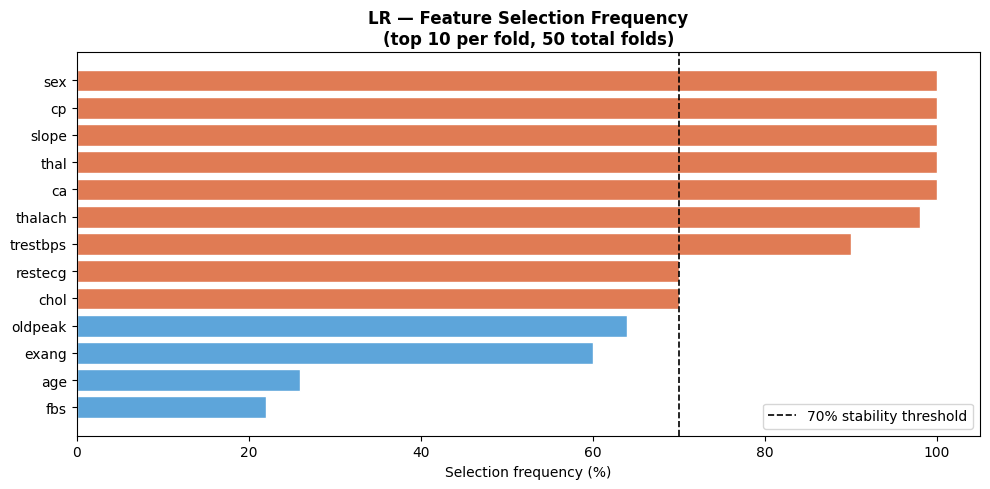

In [ ]:
# ── Bar chart of selection frequency ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#E07B54' if pct >= 70 else '#5DA5DA'
          for pct in freq_df['selected_%']]

ax.barh(freq_df.index, freq_df['selected_%'], color=colors, edgecolor='white')
ax.axvline(70, color='black', lw=1.2, ls='--', label='70% stability threshold')
ax.set_xlabel('Selection frequency (%)')
ax.set_title(f'{WINNER_NAME} — Feature Selection Frequency\n'
             f'(top {N_FEATURES} per fold, {rncv_fs.R * rncv_fs.N} total folds)',
             fontweight='bold')
ax.legend()
ax.invert_yaxis()  # most frequent on top
plt.tight_layout()
plt.savefig('../figures/fig_feature_selection_frequency.png', bbox_inches='tight', dpi=130)
plt.show()